In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib as mpl

In [2]:
df = pd.read_csv('times.csv')

In [3]:
go_times = df['go'].values.astype(float)
gr_times = df['gr'].values.astype(float)
grad_times = df['grad'].values.astype(float)
lang_times = df['lang'].values.astype(float)
sr_times = df['sr'].values[0:-3].astype(float)

In [4]:
x = df["N"].values

In [5]:
x_sr = x[0:-3]

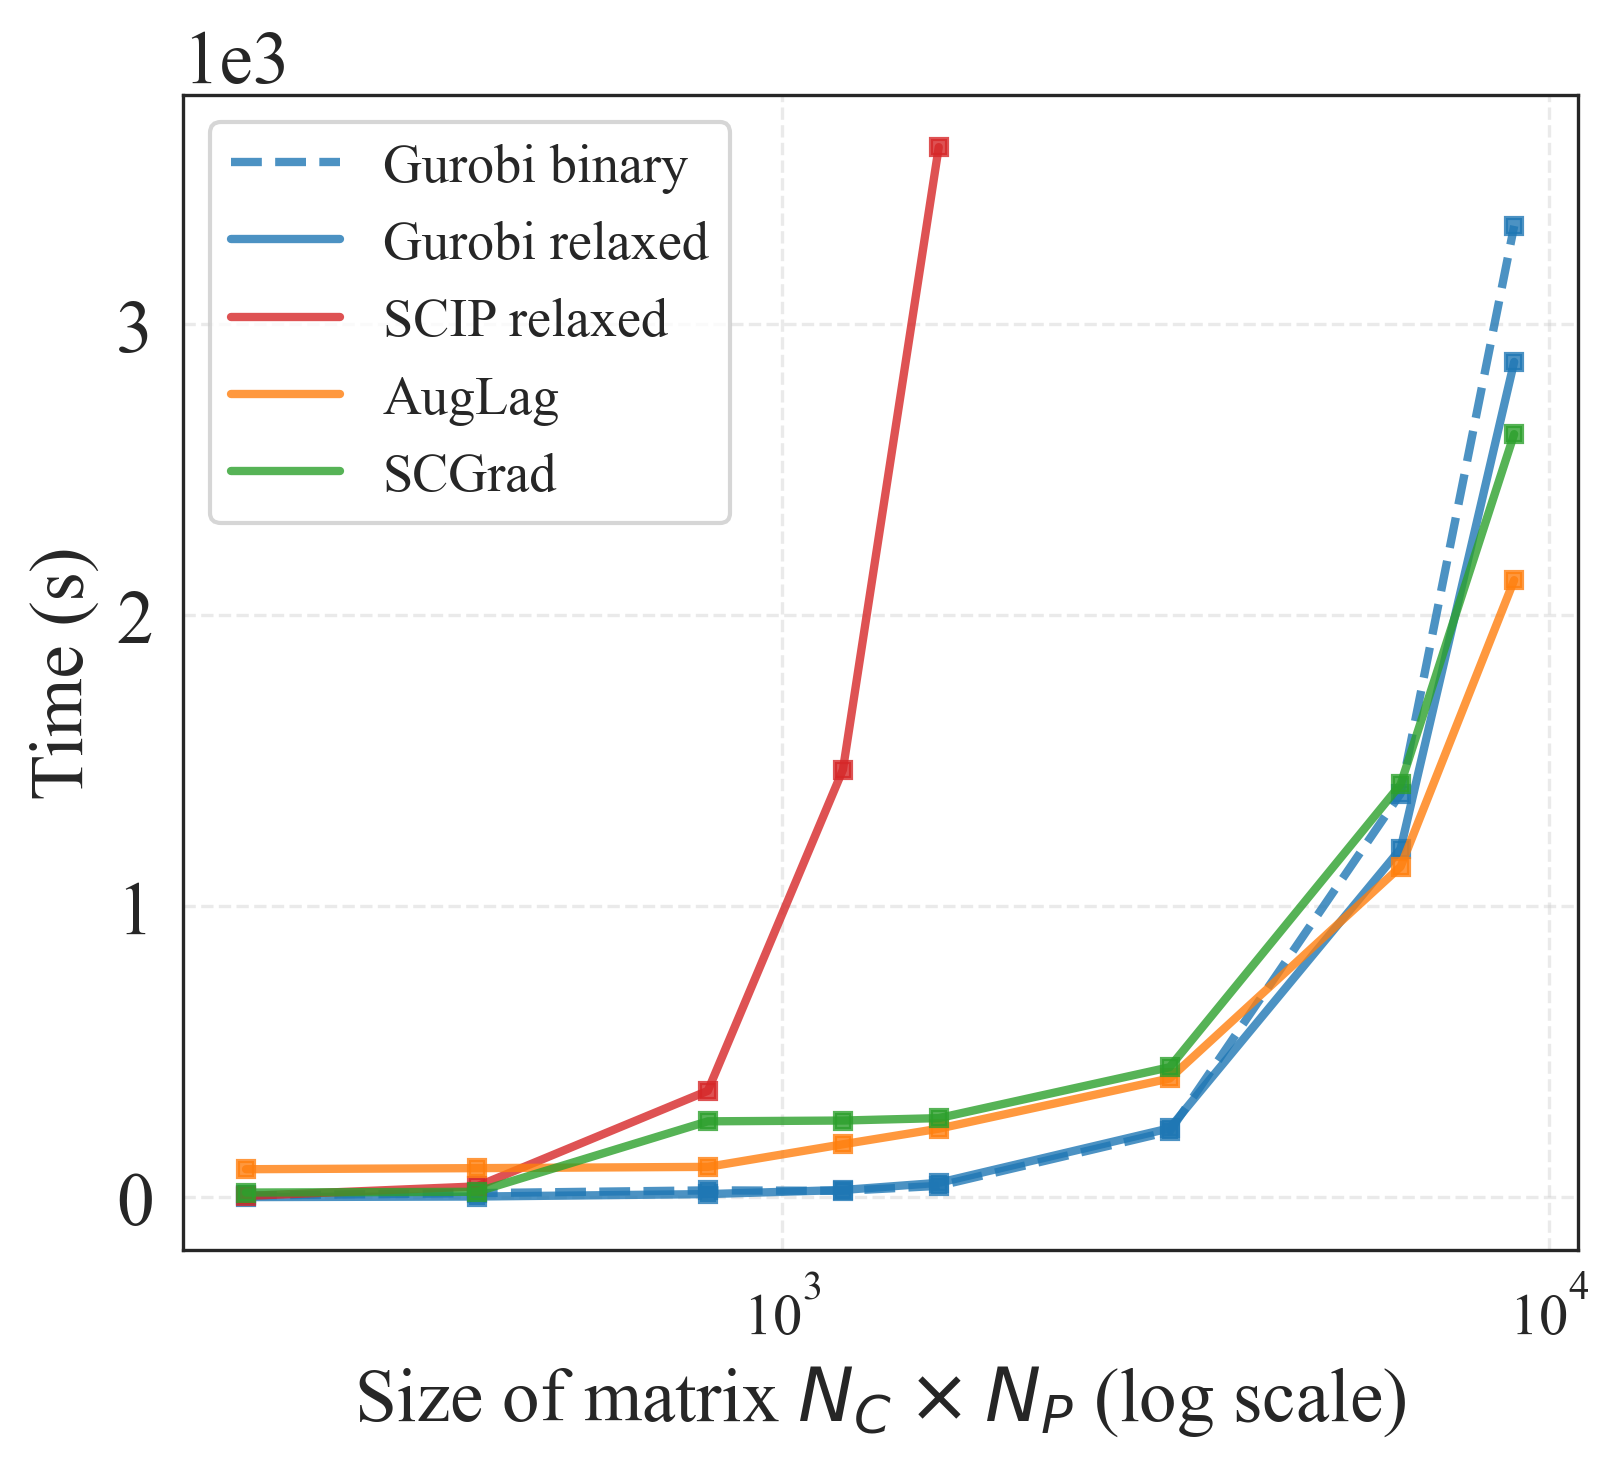

In [6]:
palette = ["#1f77b4", "#d62728", "#2ca02c", "#ff7f0e"]
sns.set_palette(palette)

mpl.rc('font', **{'size': 18})
sns.set_style("white")
plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
plt.grid(True, linestyle="--", alpha=0.4)
plt.plot(x, go_times, marker='s', linewidth=2, label='Gurobi binary', color=palette[0], linestyle='--', markersize=4, alpha=0.8)
plt.plot(x, gr_times, marker='s', linewidth=2, label='Gurobi relaxed', color=palette[0], markersize=4, alpha=0.8)
plt.plot(x_sr, sr_times, marker='s', linewidth=2, label='SCIP relaxed', color=palette[1], markersize=4, alpha=0.8)
plt.plot(x, lang_times, marker='s', linewidth=2, label='AugLag', color=palette[3], markersize=4, alpha=0.8)
plt.plot(x, grad_times, marker='s', linewidth=2, label='SCGrad', color=palette[2], markersize=4, alpha=0.8)
# put legend outside the plot
plt.legend(loc='upper left', fontsize=13, markerscale=0)
# use scientific notation for x-axis
plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
plt.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
plt.xticks(x, x**2, fontsize=14)
plt.xscale('log')

plt.ylabel('Time (s)', fontsize=18)
plt.xlabel('Size of matrix $N_{C} \\times N_{P}$ (log scale)', fontsize=18)
plt.savefig('times.pdf', bbox_inches='tight')
# set xtick labels

In [7]:
df = pd.read_csv('errors.csv')

In [8]:
gp = df['gp'].values.astype(float) * 100
gc = df['gc'].values.astype(float) * 100
lp = df['lp'].values.astype(float) * 100
lc = df['lc'].values.astype(float) * 100
x = df["N"].values

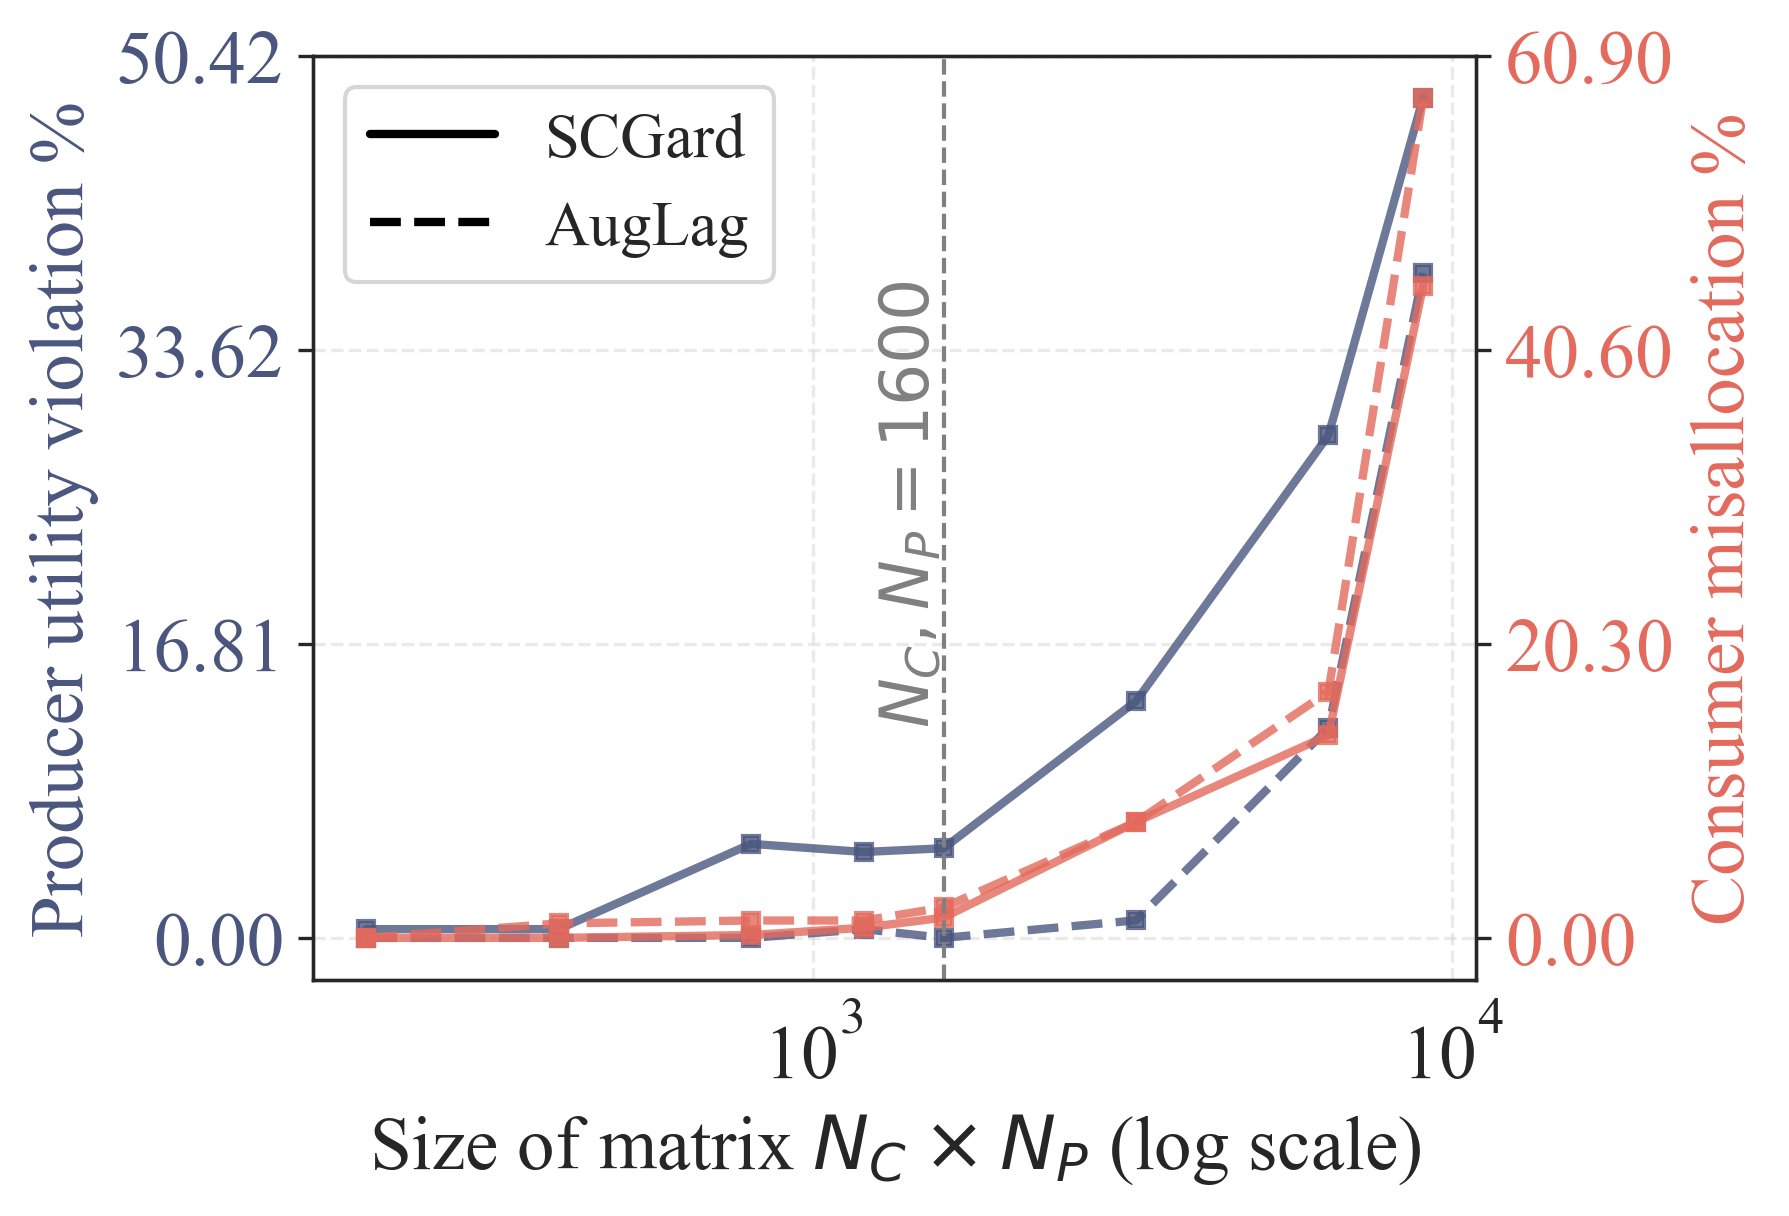

In [9]:
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

palette = ["#4A567E", "#e36a5d"]

sns.set_palette(palette)

mpl.rc('font', **{'size': 18})
sns.set_style("white")
plt.rcParams["font.family"] = "Times New Roman"

fig, ax = plt.subplots(figsize=(5, 4), dpi=300)
plt.grid(True, linestyle="--", alpha=0.4)
ax.plot(x, gp, marker='s', linewidth=2, color=palette[0], markersize=4, alpha=0.8)
ax.plot(x, lp, marker='s', linewidth=2, color=palette[0], linestyle='--', markersize=4, alpha=0.8)
ax2 = ax.twinx()
ax2.plot(x, gc, marker='s', linewidth=2, color=palette[1], markersize=4, alpha=0.8)
ax2.plot(x, lc, marker='s', linewidth=2, color=palette[1], linestyle='--', markersize=4, alpha=0.8)
# color y axis ticks
ax.tick_params(axis='y', labelcolor=palette[0])
ax.set_ylabel('Producer utility violation %', fontsize=18, color=palette[0])
ax2.tick_params(axis='y', labelcolor=palette[1])
ax2.set_ylabel('Consumer misallocation %', fontsize=18, color=palette[1])
# plot 4 values for y-axis ticks
axy_max = ax.get_ylim()[1]
ax2_max = ax2.get_ylim()[1]
ax.set_yticks(np.linspace(0, axy_max, 4))
ax2.set_yticks(np.linspace(0, ax2_max, 4))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.xlabel('Size of matrix $N_{C} \\times N_{P}$ (log scale)', fontsize=18)
plt.xticks(x, x**2, fontsize=14)
plt.xscale('log')
ax.set_xlabel('Size of matrix $N_{C} \\times N_{P}$ (log scale)', fontsize=18)
# add vertical line at x=1600 with added text
plt.axvline(x=1600, color='gray', linestyle='--', linewidth=1)
plt.text(1600, 30, '$N_{C},N_{P}=1 600$', color='gray', fontsize=16, rotation=90, va='center', ha='right')
plt.legend(handles=[Line2D([0], [0], color="black", linestyle="-", linewidth=2, label="SCGard"), Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="AugLag")],
              loc='upper left', fontsize="small")
plt.savefig('errors.pdf', bbox_inches='tight')

